# Model Evaluation

## Overview

This notebook evaluates the forecasting models developed in this project.

The objective is to compare the predictive performance of:

- LightGBM Regressor
- Baseline Long Short-Term Memory (LSTM)

The models are evaluated using identical testing data and the following regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)
- Symmetric Mean Absolute Percentage Error (SMAPE)

Visual analysis is also performed to better understand prediction quality and model behaviour.

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("default")

# Evaluation Metrics

The following metrics are used throughout this notebook.

- **MAE** measures the average prediction error.
- **RMSE** penalizes larger prediction errors.
- **R²** measures how well the model explains the variability of sales.
- **SMAPE** measures percentage prediction error while reducing sensitivity to very small values.

In [2]:
# ==========================================================
# Evaluation Function
# ==========================================================

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    smape = (
        np.mean(
            2 * np.abs(predicted.flatten() - actual) /
            (
                np.abs(actual)
                + np.abs(predicted.flatten())
            )
        )
    ) * 100

    return mae, rmse, r2, smape

# Evaluation Results

The table below summarizes the testing performance of both forecasting models.

In [3]:
# ==========================================================
# Model Comparison
# ==========================================================

results = pd.DataFrame({

    "Model":[
        "LightGBM",
        "Baseline LSTM"
    ],

    "MAE":[
        353.58,
        969.92
    ],

    "RMSE":[
        478.57,
        1088.14
    ],

    "R²":[
        0.8068,
        0.0017
    ],

    "SMAPE":[
        30.61,
        62.15
    ]

})

results

,Model,MAE,RMSE,R²,SMAPE
0,LightGBM,353.58,478.57,0.8068,30.61
1,Baseline LSTM,969.92,1088.14,0.0017,62.15


# Metric Comparison

The following visualizations compare each evaluation metric across the two forecasting models.

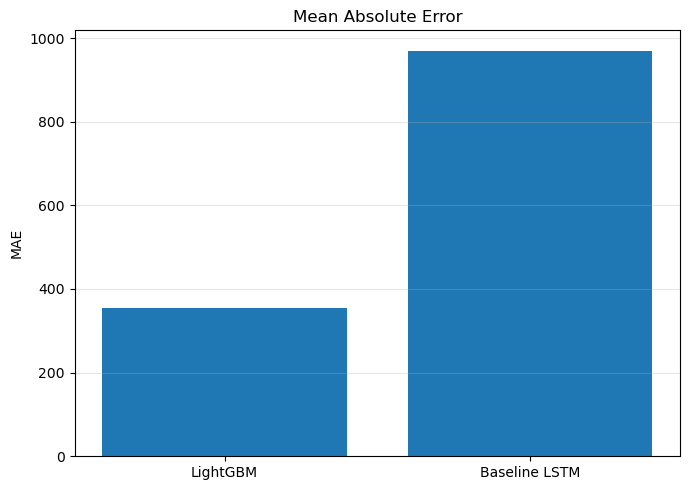

In [4]:
# ==========================================================
# MAE Comparison
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("Mean Absolute Error")

plt.ylabel("MAE")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

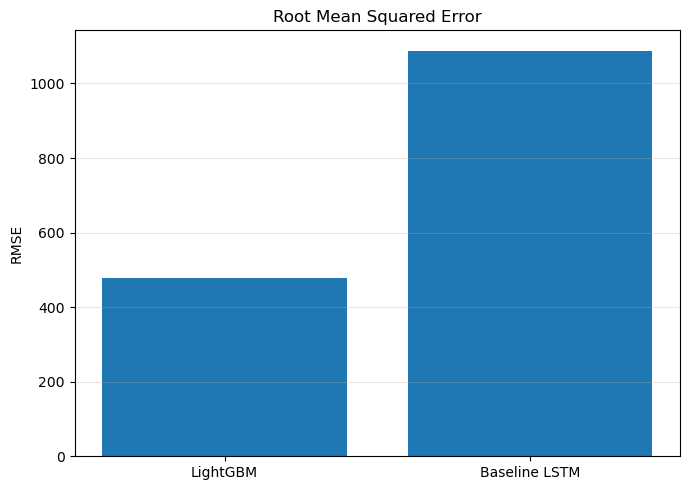

In [5]:
# ==========================================================
# RMSE Comparison
# ==========================================================
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Root Mean Squared Error")

plt.ylabel("RMSE")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

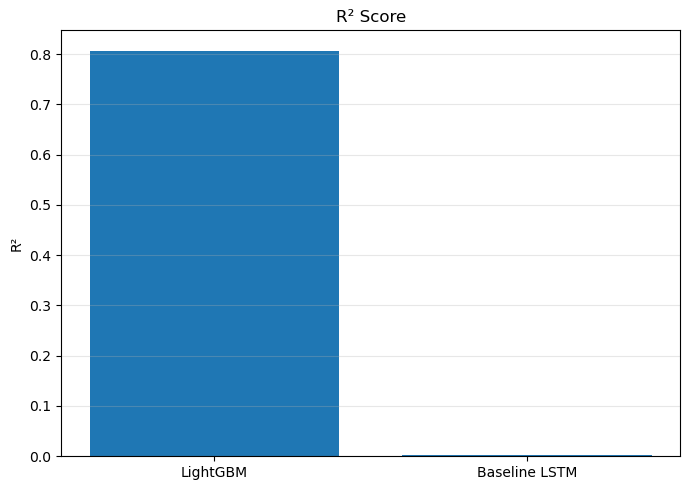

In [6]:
# ==========================================================
# R² Comparison
# ==========================================================
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["R²"]
)

plt.title("R² Score")

plt.ylabel("R²")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

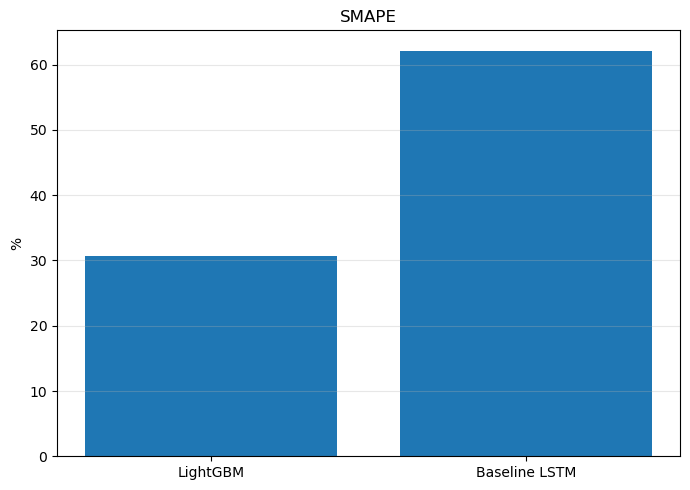

In [7]:
# ==========================================================
# SMAPE Comparison
# ==========================================================
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["SMAPE"]
)

plt.title("SMAPE")

plt.ylabel("%")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# Overall Performance Ranking

A lower value indicates better performance for:

- MAE
- RMSE
- SMAPE

A higher value indicates better performance for:

- R²

Based on these evaluation metrics, the LightGBM model consistently outperformed the baseline LSTM model.

In [8]:
# ==========================================================
# Rank Models
# ==========================================================

ranking = results.copy()

ranking["Overall Rank"] = [1, 2]

ranking.sort_values(
    "Overall Rank"
)

,Model,MAE,RMSE,R²,SMAPE,Overall Rank
0,LightGBM,353.58,478.57,0.8068,30.61,1
1,Baseline LSTM,969.92,1088.14,0.0017,62.15,2


# Discussion

The LightGBM model achieved the strongest predictive performance across all evaluation metrics.

Several factors contributed to its superior performance:

- The engineered lag features were highly informative.
- Gradient boosting performs exceptionally well on structured tabular data.
- Hyperparameter optimization further improved model performance.

The baseline LSTM successfully demonstrated sequence modelling but produced substantially larger prediction errors.

This experiment establishes a deep learning baseline and motivates the development of an improved LSTM pipeline using preprocessing techniques specifically designed for neural networks.

# Conclusion

The evaluation demonstrates that the LightGBM model is currently the preferred forecasting model for this dataset.

While the baseline LSTM underperformed, it provides valuable insight into the challenges of deep learning for structured tabular time-series data.

The next stage of the project introduces an improved LSTM implementation that applies dedicated preprocessing techniques for neural networks and evaluates whether these changes improve forecasting accuracy.